# GRASP Library Designer

For biologists: pick options in the **control panel**, then run the remaining cells top-to-bottom.

Uses Farley et al. *NAR* 2025 GRASP modules. Cut indices stay fixed; only synonymous DNA is redesigned.

**Google Colab:** run the *Colab install* and *Colab settings (Forms)* cells below. Use each cell’s ⋮ menu → **Form → Hide code** (or rely on `{display-mode: "form"}`). Local Cursor/Jupyter can keep using the ipywidgets control panel.


### First run

1. Select kernel: `grasp-library-designer/.venv`
2. Run the install cell once, then run cells top-to-bottom
3. Use the control-panel dropdowns, then click **Apply settings**
4. When you reach the redesign / optimize cells — **re-run that cell** to execute  
   (Cursor/VS Code often breaks widget button clicks; cell run always works)

Set `RUN_OVERHANG_REDESIGN = False` or `RUN_LIBRARY_OPTIMIZE = False` at the top of those cells to skip.


## Google Colab setup

If you are **not** in Colab, skip the next two cells and continue with the normal install / control panel.


In [ ]:
#@title Colab · Install private repo { display-mode: "form" }
#@markdown Skip outside Colab. For a private repo, paste a GitHub personal access token with `repo` scope.

GITHUB_TOKEN = "" #@param {type:"string"}
REPO_SLUG = "JustABiologist/grasp-library-designer" #@param {type:"string"}
BRANCH = "main" #@param {type:"string"}

import os, sys, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if not IN_COLAB:
    print("Not in Colab — skip this cell.")
else:
    repo_dir = Path("/content/grasp-library-designer")
    if not (repo_dir / "grasp_library").is_dir():
        if not REPO_SLUG or REPO_SLUG.startswith("OWNER/"):
            raise ValueError("Set REPO_SLUG to your GitHub owner/repo.")
        auth = f"{GITHUB_TOKEN}@" if GITHUB_TOKEN.strip() else ""
        url = f"https://{auth}github.com/{REPO_SLUG}.git"
        print(f"Cloning github.com/{REPO_SLUG} @ {BRANCH} …")
        subprocess.check_call(["git", "clone", "--depth", "1", "-b", BRANCH, url, str(repo_dir)])
    os.chdir(repo_dir)
    sys.path.insert(0, str(repo_dir))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", "."])
    print("Installed at", repo_dir)


In [ ]:
#@title Colab · Settings (Forms) { display-mode: "form" }
#@markdown Applies the same options as the widget control panel. Run this instead of (or after) the panel when using Colab.

target_rna = "UUACACGUG" #@param {type:"string"}
organism = "Escherichia coli (Kazusa)" #@param ["Escherichia coli (Kazusa)", "Saccharomyces cerevisiae (Kazusa)", "Homo sapiens (Kazusa)", "Euglena gracilis nuclear (Kazusa)", "Chlamydomonas reinhardtii nuclear (Kazusa)", "Chlamydomonas reinhardtii chloroplast (Kazusa)"]
genetic_code = 1 #@param {type:"integer"}
nterm_overhang = "AGGT" #@param ["AGGT", "AATG"]
architecture = "9S" #@param ["9S", "14S", "19S"]
synthesis_vendor = "Twist \u00b7 Standard gene guidelines" #@param ["Twist \u00b7 Express / Low complexity", "Twist \u00b7 Standard gene guidelines", "Twist \u00b7 Complex Genes tolerant", "IDT \u00b7 gBlocks / eBlocks conservative", "Generic \u00b7 conservative (default)"]
assembly_enzyme = "GRASP default \u00b7 BsaI + BpiI + BsmBI" #@param ["GRASP default \u00b7 BsaI + BpiI + BsmBI", "BsaI (GGTCTC)", "BpiI / BbsI (GAAGAC)", "BsmBI / Esp3I (CGTCTC)", "None (no enzyme filter)"]
ligation_table = "T4 \u00b7 18 h \u00b7 25 \u00b0C (Potapov)" #@param ["T4 \u00b7 18 h \u00b7 25 \u00b0C (Potapov)", "T4 \u00b7 18 h \u00b7 37 \u00b0C (Potapov)", "T4 \u00b7 1 h \u00b7 25 \u00b0C (Potapov)", "BsaI-HFv2 \u00b7 constant 37 \u00b0C", "BsmBI-v2 \u00b7 constant 42 \u00b0C"]
overhang_redesign = True #@param {type:"boolean"}
redesign_selection = "knee" #@param ["knee", "max_fidelity"]
optimize_depth = 2000 #@param {type:"integer"}

from pathlib import Path
from grasp_library import build_default_config
from grasp_library.colab_forms import apply_form_settings
from grasp_library import notebook_ui as ui

# Prefer globals created by the main setup cell; otherwise bootstrap.
if "INPUT_DIR" not in globals():
    PROJECT_DIR = Path("grasp_library_project")
    INPUT_DIR = PROJECT_DIR / "input"
    OUTPUT_DIR = PROJECT_DIR / "output"
    INPUT_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if "CONFIG" not in globals() or CONFIG is None:
    CONFIG = build_default_config(INPUT_DIR)

applied = apply_form_settings(
    CONFIG,
    organism=organism,
    genetic_code=int(genetic_code),
    target_rna=target_rna,
    nterm_overhang=nterm_overhang,
    architecture=architecture,
    synthesis_vendor=synthesis_vendor,
    assembly_enzyme=assembly_enzyme,
    ligation_table=ligation_table,
    overhang_redesign=bool(overhang_redesign),
    redesign_selection=redesign_selection,
    optimize_depth=int(optimize_depth),
)
CONFIG = applied["config"]
CODON_DATA = applied["codon_data"]
CODON_TABLE = applied["codon_table"]
SELECTED_ORGANISM = organism

ui.status(
    f"Colab Forms applied · target <b>{CONFIG['target_rna']}</b> · "
    f"<b>{organism}</b> · redesign <b>{CONFIG['overhang_redesign']['enabled']}</b> · "
    f"depth <b>{CONFIG['optimizer']['iterations_per_part']:,}</b>"
)


In [1]:
%pip install -q pandas numpy biopython pyyaml openpyxl matplotlib ipywidgets



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline

from pathlib import Path
from collections import Counter, defaultdict
from itertools import product
from dataclasses import dataclass, asdict
from copy import deepcopy

import json
import math
import random
import re

import numpy as np
import pandas as pd
import yaml
import ipywidgets as widgets

from Bio.Seq import Seq
from Bio import SeqIO
from IPython.display import display, clear_output

from grasp_library import (
    LigationFidelityCalculator,
    optimize_pareto_overhangs,
    knee_point,
    SAMPLE_CODON_TABLES,
    sample_names,
    write_sample_codon_table,
    codon_table_dataframe,
    import_grasp_profile,
    compile_target_gap,
    GraspControlPanel,
    build_default_config,
    wire_reload_button,
    SYNTHESIS_VENDORS,
    twist_length_advice,
    vendor_names,
    run_overhang_redesign,
    run_library_optimize,
    plot_pareto_front,
    rescore_pareto_front_after_anneal,
    load_codon_usage,
    apply_organism_codon_table,
)
from grasp_library import notebook_ui as ui
# Package loader always re-derives AA from the active genetic code
from grasp_library.codon_tables import load_codon_usage as load_codon_usage

ui.hero()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_DIR = Path("grasp_library_project")
INPUT_DIR = PROJECT_DIR / "input"
OUTPUT_DIR = PROJECT_DIR / "output"
PROFILE_DIR = PROJECT_DIR / "profiles"
for d in (INPUT_DIR, OUTPUT_DIR, PROFILE_DIR):
    d.mkdir(parents=True, exist_ok=True)

ui.status(f"Project folder: <code>{PROJECT_DIR.resolve()}</code>")

# Shared run state
CODON_TABLE = None
CODON_DATA = {}
SELECTED_ORGANISM = "Escherichia coli (Kazusa)"
parts = None
target_map = None
PARETO_FRONT = None
SELECTED_OVERHANGS = None
parts_with_redesigned_junctions = None
optimized_library = None
PANEL = None


In [3]:
ui.section(
    "Configuration object",
    "Defaults follow Twist Standard gene guidelines. The control panel overwrites these when you click Apply.",
)

CONFIG = build_default_config(INPUT_DIR)

# Show Twist / vendor cheat-sheet
rows = []
for name, prof in SYNTHESIS_VENDORS.items():
    if prof["synthesis"] is None:
        continue
    s = prof["synthesis"]
    rows.append({
        "Profile": name,
        "GC%": f"{s['global_gc_min']*100:.0f}–{s['global_gc_max']*100:.0f}",
        "Window": f"{s['window_size']} bp · {s['window_gc_min']*100:.0f}–{s['window_gc_max']*100:.0f}%",
        "Max HP": s["max_homopolymer"],
        "Repeat k": s["repeat_k"],
    })
display(pd.DataFrame(rows))
ui.note(
    "Twist hard rules: avoid homopolymers ≥14 bp; do not include CcdB. "
    "Final Twist acceptance is ML-scored — these profiles approximate published guidelines. "
    "Sources: Twist FAQ + Complex Genes pages."
)


,Profile,GC%,Window,Max HP,Repeat k
0,Twist · Express / Low complexity,25–65,50 bp · 20–80%,9,12
1,Twist · Standard gene guidelines,25–65,50 bp · 15–85%,13,16
2,Twist · Complex Genes tolerant,25–75,50 bp · 10–90%,30,20
3,IDT · gBlocks / eBlocks conservative,25–70,40 bp · 20–80%,8,12
4,Generic · conservative (default),30–65,40 bp · 25–75%,6,12


## DNA / protein helpers

In [4]:
DNA_ALPHABET = set("ACGT")
MASK_ALPHABET = set("ACGTN")


def clean_dna(sequence):
    """Normalize and validate DNA."""
    sequence = str(sequence).upper().replace("U", "T")
    sequence = re.sub(r"\s+", "", sequence)

    invalid = set(sequence) - DNA_ALPHABET
    if invalid:
        raise ValueError(f"Invalid DNA characters: {invalid}")

    return sequence


def clean_mask(mask):
    """Normalize and validate nucleotide mask."""
    mask = str(mask).upper().replace("U", "T")
    mask = re.sub(r"\s+", "", mask)

    invalid = set(mask) - MASK_ALPHABET
    if invalid:
        raise ValueError(f"Invalid mask characters: {invalid}")

    return mask


def reverse_complement(sequence):
    return str(Seq(sequence).reverse_complement())


def translate_dna(sequence, genetic_code=1):
    sequence = clean_dna(sequence)

    if len(sequence) % 3 != 0:
        raise ValueError("CDS length is not divisible by three.")

    return str(Seq(sequence).translate(table=genetic_code))


def gc_fraction(sequence):
    sequence = clean_dna(sequence)
    if not sequence:
        return 0.0
    return (sequence.count("G") + sequence.count("C")) / len(sequence)


def mask_matches(sequence, mask):
    sequence = clean_dna(sequence)
    mask = clean_mask(mask)

    if len(sequence) != len(mask):
        return False

    return all(
        mask_base == "N" or sequence_base == mask_base
        for sequence_base, mask_base in zip(sequence, mask)
    )


def longest_homopolymer(sequence):
    sequence = clean_dna(sequence)
    return max(
        (len(match.group(0)) for match in re.finditer(r"(A+|C+|G+|T+)", sequence)),
        default=0
    )


def kmer_counts(sequence, k):
    sequence = clean_dna(sequence)

    if len(sequence) < k:
        return Counter()

    return Counter(
        sequence[i:i+k]
        for i in range(len(sequence) - k + 1)
    )


def repeated_kmer_penalty(sequence, k=12):
    counts = kmer_counts(sequence, k)
    return sum((count - 1) ** 2 for count in counts.values() if count > 1)


def local_gc_penalty(
    sequence,
    window_size,
    gc_min,
    gc_max,
):
    sequence = clean_dna(sequence)

    if len(sequence) <= window_size:
        value = gc_fraction(sequence)
        if value < gc_min:
            return (gc_min - value) ** 2
        if value > gc_max:
            return (value - gc_max) ** 2
        return 0.0

    penalty = 0.0

    for start in range(len(sequence) - window_size + 1):
        window = sequence[start:start + window_size]
        value = gc_fraction(window)

        if value < gc_min:
            penalty += (gc_min - value) ** 2
        elif value > gc_max:
            penalty += (value - gc_max) ** 2

    return penalty


def contains_forbidden_site(sequence, forbidden_sites):
    """Check both DNA strands."""
    sequence = clean_dna(sequence)

    hits = []

    for name, motif in forbidden_sites.items():
        motif = clean_dna(motif)
        motifs = {motif, reverse_complement(motif)}

        for query in motifs:
            start = sequence.find(query)
            while start != -1:
                hits.append({
                    "enzyme": name,
                    "site": query,
                    "start_0based": start,
                })
                start = sequence.find(query, start + 1)

    return hits


def is_self_reverse_complement(overhang):
    overhang = clean_dna(overhang)
    return overhang == reverse_complement(overhang)


## Codon table helper

Defined before the organism dropdown so Apply can normalize frequencies immediately.


In [5]:
def load_codon_usage(path, genetic_code=1):
    table = pd.read_csv(path)
    table.columns = [str(column).strip().lower() for column in table.columns]

    required = {"codon", "frequency"}
    missing = required - set(table.columns)

    if missing:
        raise ValueError(
            f"Codon table requires columns {required}. "
            f"Fehlend: {missing}"
        )

    table["codon"] = (
        table["codon"]
        .astype(str)
        .str.upper()
        .str.replace("U", "T", regex=False)
        .str.replace(r"\s+", "", regex=True)
    )

    table["frequency"] = pd.to_numeric(table["frequency"], errors="raise")

    for codon in table["codon"]:
        if len(codon) != 3 or set(codon) - set("ACGT"):
            raise ValueError(f"Invalid codon: {codon}")

    if "aa" not in table.columns:
        table["aa"] = [
            str(Seq(codon).translate(table=genetic_code))
            for codon in table["codon"]
        ]
    else:
        table["aa"] = table["aa"].astype(str).str.upper()

    # Exclude stop codons from normal optimization
    table = table[table["aa"] != "*"].copy()

    if (table["frequency"] < 0).any():
        raise ValueError("Codon frequencies must not be negative.")

    if table.groupby("aa")["frequency"].sum().eq(0).any():
        raise ValueError(
            "At least one amino acid has all frequencies equal to zero."
        )

    table["aa_total"] = table.groupby("aa")["frequency"].transform("sum")
    table["probability"] = table["frequency"] / table["aa_total"]

    table["aa_max"] = table.groupby("aa")["frequency"].transform("max")
    table["relative_adaptiveness"] = table["frequency"] / table["aa_max"]

    codon_data = defaultdict(list)

    for row in table.itertuples(index=False):
        codon_data[row.aa].append({
            "codon": row.codon,
            "frequency": float(row.frequency),
            "probability": float(row.probability),
            "relative_adaptiveness": float(row.relative_adaptiveness),
        })

    return table, dict(codon_data)


In [6]:
PANEL = GraspControlPanel(
    CONFIG,
    input_dir=INPUT_DIR,
)

def _on_panel_apply(cfg):
    global CODON_TABLE, CODON_DATA, SELECTED_ORGANISM, CONFIG, TARGET_RNA
    CONFIG = cfg
    CODON_TABLE = PANEL.CODON_TABLE
    CODON_DATA = PANEL.CODON_DATA
    SELECTED_ORGANISM = PANEL.SELECTED_ORGANISM
    TARGET_RNA = cfg.get("target_rna", "UUACACGUG")

PANEL.on_apply = _on_panel_apply

def _reload_grasp():
    profile = PROJECT_DIR / "profiles" / "grasp_nar2025" / "genbank"
    return import_grasp_profile(profile, INPUT_DIR)

wire_reload_button(PANEL, _reload_grasp)
PANEL.display()

# Convenience alias used by later cells
TARGET_RNA = CONFIG.get("target_rna", "UUACACGUG")


▶ Host set to Escherichia coli (code 1, 61 sense codons)


## Confirm active settings

Re-run if you changed dropdowns and clicked **Apply settings**.


In [10]:
ui.section(
    "Confirm codon table & synthesis profile",
    "Normalized frequencies + active vendor constraints.",
)

try:
    if not CODON_DATA:
        raise RuntimeError("Open the control panel and click Apply settings first.")
    ui.status(
        f"Organism: <b>{SELECTED_ORGANISM}</b> · "
        f"{len(CODON_TABLE)} sense codons · "
        f"vendor <b>{CONFIG.get('synthesis_vendor')}</b> · "
        f"enzyme <b>{CONFIG.get('assembly_enzyme')}</b>"
    )
    display(
        CODON_TABLE.sort_values("relative_adaptiveness", ascending=False)
        .groupby("aa", as_index=False)
        .first()[["aa", "codon", "frequency", "relative_adaptiveness"]]
        .head(12)
    )
    synth = CONFIG["synthesis"]
    print(
        f"Synthesis limits: GC {synth['global_gc_min']:.2f}-{synth['global_gc_max']:.2f}, "
        f"window={synth['window_size']}, max_HP={synth['max_homopolymer']}, "
        f"repeat_k={synth['repeat_k']}"
    )
    print("Twist length tip (example 120 bp module):", twist_length_advice(120))
except Exception as error:
    ui.note(str(error))


,aa,codon,frequency,relative_adaptiveness
0,A,GCC,54.6,1.0
1,C,TGC,13.1,1.0
2,D,GAC,41.7,1.0
3,E,GAG,53.5,1.0
4,F,TTC,27.1,1.0
5,G,GGC,62.0,1.0
6,H,CAC,17.2,1.0
7,I,ATC,26.6,1.0
8,K,AAG,43.3,1.0
9,L,CTG,65.2,1.0


Synthesis limits: GC 0.25-0.65, window=50, max_HP=9, repeat_k=12
Twist length tip (example 120 bp module): 120 bp fits Twist oligo pools (20–300 bp). Gene Fragments / Clonal Genes need ≥300 bp (pad or order as oligos).


# Project inputs

Files under `grasp_library_project/input/` are filled from the deposited GRASP GenBank modules (Farley et al., NAR 2025).

### `parts.csv`
42 level −1 modules: `part_id`, `aa_sequence`, `coding_mask`, `oligo_prefix`, `oligo_suffix`.

### `junction_map.csv`
Fixed DNA indices for the 7 unique 9S overhangs (`mask_start_0based`). Cut positions stay as in GRASP; only the 4-nt sequence is redesigned.

### `overhang_candidates.csv`
Native overhangs plus synonym-compatible 4-mers at those fixed indices.

### `target_map.csv`
Catalog of module codes. Assembly plans use the paper’s GAP algorithm (`compile_target_gap`), not a 1:1 base→part table — middle motifs split 5th/last across adjacent modules.


In [11]:
ui.section(
    "Load GRASP profile from deposited GenBank",
    "Sequences, fixed cut indices, and flanks come from Farley et al. NAR 2025 "
    "(github.com/farleykvdg/GRASP). Nothing is invented.",
)

PROFILE_GB = PROJECT_DIR / "profiles" / "grasp_nar2025" / "genbank"

# Fast path: reuse CSVs if already imported (Reload button forces refresh)
_parts_path = INPUT_DIR / "parts.csv"
if _parts_path.exists() and "REPLACE" not in _parts_path.read_text()[:500]:
    parts_preview = pd.read_csv(_parts_path)
    junction_preview = pd.read_csv(INPUT_DIR / "junction_map.csv")
    candidate_preview = pd.read_csv(INPUT_DIR / "overhang_candidates.csv")
    target_map_preview = pd.read_csv(INPUT_DIR / "target_map.csv")
    ui.status(
        f"Using cached import: <b>{len(parts_preview)}</b> modules · "
        f"<b>{junction_preview['junction'].nunique()}</b> junctions · "
        f"<b>{len(candidate_preview)}</b> overhang candidates<br/>"
        f"Click <b>Reload GRASP GenBank</b> in the control panel to re-parse GenBank."
    )
else:
    imported = import_grasp_profile(PROFILE_GB, INPUT_DIR)
    parts_preview = imported["parts"]
    junction_preview = imported["junction_map"]
    candidate_preview = imported["overhang_candidates"]
    target_map_preview = imported["target_map"]
    ui.status(
        f"Imported <b>{len(parts_preview)}</b> modules · "
        f"<b>{junction_preview['junction'].nunique()}</b> redesign junctions · "
        f"<b>{len(candidate_preview)}</b> synonym overhang candidates<br/>"
        f"Source: <code>{PROFILE_GB}</code>"
    )

display(parts_preview.head())
display(junction_preview.groupby("junction", as_index=False).first()[
    ["junction", "native_overhang"]
])

# Make parts available to later cells / buttons
parts = parts_preview.copy()
target_map = target_map_preview.copy()


,part_id,aa_sequence,coding_mask,oligo_prefix,oligo_suffix
0,14A_LD5N,SELFDKMPERDVVSWNAMISGYAQNGRIDEAREL,NGTGANNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,ACATCTC,TTGTCTTC
1,14A_LD5T,SELFDKMPERDVVSWTAMISGYAQNGRIDEAREL,NGTGANNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,ACATCTC,TTGTCTTC
2,14A_LN5N,SELFDKMPERNVVSWNAMISGYAQNGRIDEAREL,NGTGANNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,ACATCTC,TTGTCTTC
3,14A_LN5T,SELFDKMPERNVVSWTAMISGYAQNGRIDEAREL,NGTGANNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,ACATCTC,TTGTCTTC
4,14E_LD5N,IELFDKMPERDVVSWNAMISGYAQNGRIDEARD,NNTGAANNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,AC,GAGTTGTCTTC


,junction,native_overhang
0,J_AAGA,AAGA
1,J_ACTC,ACTC
2,J_CTTC,CTTC
3,J_Cterm,TTCG
4,J_GCAC,GCAC
5,J_Nterm,AGGT
6,J_TGAA,TGAA


# Masked codon optimization

## Allowed codons under the coding mask


In [12]:
def codon_matches_mask(codon, codon_mask):
    return all(
        mask_base == "N" or codon_base == mask_base
        for codon_base, mask_base in zip(codon, codon_mask)
    )


def build_allowed_codons(
    aa_sequence,
    coding_mask,
    codon_data,
    minimum_relative_adaptiveness=0.20,
):
    aa_sequence = str(aa_sequence).upper().replace(" ", "")
    coding_mask = clean_mask(coding_mask)

    if len(coding_mask) != 3 * len(aa_sequence):
        raise ValueError(
            f"Mask length {len(coding_mask)} does not match "
            f"{len(aa_sequence)} amino acids. Expected: "
            f"{3 * len(aa_sequence)}."
        )

    allowed = []

    for index, amino_acid in enumerate(aa_sequence):
        if amino_acid not in codon_data:
            raise ValueError(
                f"No codons available for amino acid {amino_acid!r}."
            )

        codon_mask = coding_mask[3*index:3*index+3]

        candidates = [
            item
            for item in codon_data[amino_acid]
            if codon_matches_mask(item["codon"], codon_mask)
        ]

        if not candidates:
            raise ValueError(
                f"No synonymous codons for amino acid {amino_acid} "
                f"at position {index + 1} match the mask {codon_mask}."
            )

        preferred = [
            item for item in candidates
            if item["relative_adaptiveness"] >= minimum_relative_adaptiveness
        ]

        # Mask compatibility takes priority over codon frequency.
        allowed.append(preferred if preferred else candidates)

    return allowed


## Scoring functions

In [13]:
def codon_score(sequence, aa_sequence, codon_data, epsilon=1e-12):
    """
    Mittlerer Log-Adaptiveness-Score.
    0 ist theoretisch optimal; negativ ist schlechter.
    """
    sequence = clean_dna(sequence)
    aa_sequence = str(aa_sequence).upper()

    lookup = {}
    for aa, entries in codon_data.items():
        for entry in entries:
            lookup[(aa, entry["codon"])] = entry["relative_adaptiveness"]

    scores = []

    for index, aa in enumerate(aa_sequence):
        codon = sequence[3*index:3*index+3]
        adaptiveness = lookup.get((aa, codon), 0.0)
        scores.append(math.log(max(adaptiveness, epsilon)))

    return float(np.mean(scores))


def global_gc_penalty(sequence, gc_min, gc_max):
    value = gc_fraction(sequence)

    if value < gc_min:
        return (gc_min - value) ** 2

    if value > gc_max:
        return (value - gc_max) ** 2

    return 0.0


def library_similarity_penalty(sequence, external_kmers, k=12):
    """
    Penalizes k-mers that already occur in other library parts.
    """
    if not external_kmers:
        return 0.0

    counts = kmer_counts(sequence, k)

    return sum(
        count * external_kmers.get(kmer, 0)
        for kmer, count in counts.items()
    )


def sequence_objective(
    sequence,
    aa_sequence,
    codon_data,
    config,
    external_kmers=None,
):
    synthesis = config["synthesis"]
    weights = config["weights"]

    # Harte Ausschlussregel
    forbidden_hits = contains_forbidden_site(
        sequence,
        config["forbidden_sites"],
    )

    if forbidden_hits:
        return -1e12

    score = 0.0

    score += weights["codon"] * codon_score(
        sequence,
        aa_sequence,
        codon_data,
    )

    score -= weights["global_gc"] * global_gc_penalty(
        sequence,
        synthesis["global_gc_min"],
        synthesis["global_gc_max"],
    )

    score -= weights["local_gc"] * local_gc_penalty(
        sequence,
        synthesis["window_size"],
        synthesis["window_gc_min"],
        synthesis["window_gc_max"],
    )

    excess_homopolymer = max(
        0,
        longest_homopolymer(sequence) - synthesis["max_homopolymer"],
    )

    score -= weights["homopolymer"] * excess_homopolymer ** 2

    score -= weights["internal_repeat"] * repeated_kmer_penalty(
        sequence,
        k=synthesis["repeat_k"],
    )

    score -= weights["library_similarity"] * library_similarity_penalty(
        sequence,
        external_kmers or Counter(),
        k=synthesis["repeat_k"],
    )

    return score


## Simulated-annealing optimizer

In [14]:
def weighted_initial_sequence(allowed_codons):
    codons = []

    for candidates in allowed_codons:
        probabilities = np.array(
            [item["probability"] for item in candidates],
            dtype=float,
        )
        probabilities /= probabilities.sum()

        selected = np.random.choice(
            len(candidates),
            p=probabilities,
        )

        codons.append(candidates[selected]["codon"])

    return "".join(codons)


def greedy_coding_sequence(allowed_codons):
    """Fast encode: best relative-adaptiveness codon per position (mask-safe)."""
    codons = []
    for candidates in allowed_codons:
        best = max(candidates, key=lambda c: c["relative_adaptiveness"])
        codons.append(best["codon"])
    return "".join(codons)


def optimize_coding_sequence(
    aa_sequence,
    coding_mask,
    codon_data,
    config,
    external_kmers=None,
    iterations=None,
):
    minimum_adaptiveness = config["codon_optimization"][
        "minimum_relative_adaptiveness"
    ]

    allowed_codons = build_allowed_codons(
        aa_sequence,
        coding_mask,
        codon_data,
        minimum_relative_adaptiveness=minimum_adaptiveness,
    )

    if iterations is None:
        iterations = config["optimizer"]["iterations_per_part"]

    # iterations <= 0 → greedy only (used during Pareto search)
    if iterations <= 0:
        sequence = greedy_coding_sequence(allowed_codons)
        score = sequence_objective(
            sequence, aa_sequence, codon_data, config, external_kmers=external_kmers
        )
        return sequence, score

    current_sequence = greedy_coding_sequence(allowed_codons)
    current_codons = [
        current_sequence[i:i+3]
        for i in range(0, len(current_sequence), 3)
    ]

    current_score = sequence_objective(
        current_sequence,
        aa_sequence,
        codon_data,
        config,
        external_kmers=external_kmers,
    )

    # Few restarts if greedy hit a forbidden site
    for _ in range(30):
        if current_score > -1e11:
            break

        current_sequence = weighted_initial_sequence(allowed_codons)
        current_codons = [
            current_sequence[i:i+3]
            for i in range(0, len(current_sequence), 3)
        ]

        current_score = sequence_objective(
            current_sequence,
            aa_sequence,
            codon_data,
            config,
            external_kmers=external_kmers,
        )
    else:
        raise RuntimeError(
            "No initial sequence without forbidden sites found. "
            "The coding mask may be too restrictive."
        )

    best_sequence = current_sequence
    best_score = current_score

    mutable_positions = [
        index
        for index, candidates in enumerate(allowed_codons)
        if len(candidates) > 1
    ]

    if not mutable_positions:
        return best_sequence, best_score

    t_initial = config["optimizer"]["initial_temperature"]
    t_final = config["optimizer"]["final_temperature"]

    for iteration in range(iterations):
        fraction = iteration / max(1, iterations - 1)
        temperature = t_initial * (t_final / t_initial) ** fraction

        position = random.choice(mutable_positions)
        old_codon = current_codons[position]

        alternatives = [
            item["codon"]
            for item in allowed_codons[position]
            if item["codon"] != old_codon
        ]

        if not alternatives:
            continue

        new_codon = random.choice(alternatives)

        candidate_codons = current_codons.copy()
        candidate_codons[position] = new_codon
        candidate_sequence = "".join(candidate_codons)

        candidate_score = sequence_objective(
            candidate_sequence,
            aa_sequence,
            codon_data,
            config,
            external_kmers=external_kmers,
        )

        delta = candidate_score - current_score

        accept = (
            delta >= 0
            or random.random() < math.exp(delta / max(temperature, 1e-12))
        )

        if accept:
            current_codons = candidate_codons
            current_sequence = candidate_sequence
            current_score = candidate_score

            if current_score > best_score:
                best_sequence = current_sequence
                best_score = current_score

    # Safety checks
    if translate_dna(
        best_sequence,
        config["genetic_code"],
    ) != aa_sequence:
        raise AssertionError("Optimization changed the protein sequence.")

    if not mask_matches(best_sequence, coding_mask):
        raise AssertionError("Optimized sequence violates the coding mask.")

    return best_sequence, best_score


# Synthesis QC

## Synthesis QC


In [15]:
def synthesis_qc(sequence, config, *, forbidden_scan=None):
    """QC a DNA string.

    Forbidden Type IIS sites are scanned in `forbidden_scan` if given,
    otherwise in `sequence`. Use this to QC full oligos while only forbidding
    sites inside the CDS — GRASP oligo flanks intentionally contain BpiI
    (e.g. suffix …TTGTCTTC).
    """
    synthesis = config["synthesis"]
    sequence = clean_dna(sequence)
    scan = clean_dna(forbidden_scan) if forbidden_scan is not None else sequence

    gc = gc_fraction(sequence)
    homopolymer = longest_homopolymer(sequence)
    repeat_penalty = repeated_kmer_penalty(
        sequence,
        synthesis["repeat_k"],
    )

    forbidden_hits = contains_forbidden_site(
        scan,
        config["forbidden_sites"],
    )

    local_penalty = local_gc_penalty(
        sequence,
        synthesis["window_size"],
        synthesis["window_gc_min"],
        synthesis["window_gc_max"],
    )

    warnings = []
    failures = []

    if not (
        synthesis["global_gc_min"]
        <= gc
        <= synthesis["global_gc_max"]
    ):
        warnings.append("Global GC outside target range")

    if local_penalty > 0:
        warnings.append("Local GC outside target range")

    if homopolymer > synthesis["max_homopolymer"]:
        warnings.append("Homopolymer too long")

    if repeat_penalty > synthesis["max_repeat_count"]:
        warnings.append("Elevated internal DNA repeats")

    if forbidden_hits:
        failures.append("Forbidden restriction site in CDS")

    passed = len(failures) == 0

    return {
        "length": len(sequence),
        "gc_fraction": gc,
        "longest_homopolymer": homopolymer,
        "repeat_penalty": repeat_penalty,
        "local_gc_penalty": local_penalty,
        "forbidden_hits": json.dumps(forbidden_hits),
        "warnings": "; ".join(warnings),
        "failures": "; ".join(failures),
        "passed": passed,
    }


# Optimize the full GRASP library

## Validate parts.csv


In [16]:
def load_and_validate_parts(path):
    parts = pd.read_csv(path).fillna("")

    required = {
        "part_id",
        "aa_sequence",
        "coding_mask",
        "oligo_prefix",
        "oligo_suffix",
    }

    missing = required - set(parts.columns)

    if missing:
        raise ValueError(f"In parts.csv fehlen Spalten: {missing}")

    if parts["part_id"].duplicated().any():
        duplicates = parts.loc[
            parts["part_id"].duplicated(),
            "part_id"
        ].tolist()
        raise ValueError(f"Doppelte part_id-Werte: {duplicates}")

    for row in parts.itertuples(index=False):
        aa = str(row.aa_sequence).upper().replace(" ", "")
        mask = clean_mask(row.coding_mask)

        if "REPLACE" in aa or "REPLACE" in mask:
            continue

        if len(mask) != 3 * len(aa):
            raise ValueError(
                f"{row.part_id}: mask length {len(mask)}, expected "
                f"{3 * len(aa)}."
            )

    return parts


try:
    parts = load_and_validate_parts(CONFIG["parts_file"])

    if parts["aa_sequence"].str.contains("REPLACE").any():
        raise ValueError(
            "parts.csv still contains placeholders. "
            "Please enter exact GRASP sequences and flanks."
        )

    display(parts.head())

except Exception as error:
    print("parts.csv is still incomplete:")
    print(error)
    parts = None


,part_id,aa_sequence,coding_mask,oligo_prefix,oligo_suffix
0,14A_LD5N,SELFDKMPERDVVSWNAMISGYAQNGRIDEAREL,NGTGANNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,ACATCTC,TTGTCTTC
1,14A_LD5T,SELFDKMPERDVVSWTAMISGYAQNGRIDEAREL,NGTGANNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,ACATCTC,TTGTCTTC
2,14A_LN5N,SELFDKMPERNVVSWNAMISGYAQNGRIDEAREL,NGTGANNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,ACATCTC,TTGTCTTC
3,14A_LN5T,SELFDKMPERNVVSWTAMISGYAQNGRIDEAREL,NGTGANNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,ACATCTC,TTGTCTTC
4,14E_LD5N,IELFDKMPERDVVSWNAMISGYAQNGRIDEARD,NNTGAANNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,AC,GAGTTGTCTTC


## Optimize all modules

The notebook generates multiple synonymously coded versions per part. Previously generated sequences are kept in a k-mer bank so later parts become more DNA-orthogonal.


In [17]:
def optimize_library(parts, codon_data, config):
    results = []
    library_kmers = Counter()

    number_of_versions = config["optimizer"][
        "orthogonal_versions_per_part"
    ]
    repeat_k = config["synthesis"]["repeat_k"]

    for part_index, row in parts.iterrows():
        aa_sequence = (
            str(row["aa_sequence"])
            .upper()
            .replace(" ", "")
        )

        coding_mask = clean_mask(row["coding_mask"])

        print(
            f"[{part_index + 1}/{len(parts)}] "
            f"Optimizing {row['part_id']}"
        )

        part_versions = []

        for version in range(1, number_of_versions + 1):
            sequence, objective = optimize_coding_sequence(
                aa_sequence=aa_sequence,
                coding_mask=coding_mask,
                codon_data=codon_data,
                config=config,
                external_kmers=library_kmers,
            )

            # Full synthesis fragment:
            # Flanks in the profile must already be correctly oriented.
            full_oligo = (
                clean_dna(row["oligo_prefix"])
                + sequence
                + clean_dna(row["oligo_suffix"])
            )

            cds_qc = synthesis_qc(sequence, config)
            # Flanks carry intentional BpiI (GTCTTC) — only scan CDS for forbidden sites
            oligo_qc = synthesis_qc(
                full_oligo, config, forbidden_scan=sequence
            )

            result = {
                "part_id": row["part_id"],
                "version": version,
                "optimized_part_id": (
                    f"{row['part_id']}_v{version}"
                ),
                "aa_sequence": aa_sequence,
                "coding_mask": coding_mask,
                "optimized_cds": sequence,
                "oligo_prefix": clean_dna(row["oligo_prefix"]),
                "oligo_suffix": clean_dna(row["oligo_suffix"]),
                "oligo_sequence_5to3": full_oligo,
                "objective_score": objective,
                "codon_score": codon_score(
                    sequence,
                    aa_sequence,
                    codon_data,
                ),
                "translation_verified": (
                    translate_dna(
                        sequence,
                        config["genetic_code"],
                    ) == aa_sequence
                ),
                "mask_verified": mask_matches(
                    sequence,
                    coding_mask,
                ),
                "cds_gc": cds_qc["gc_fraction"],
                "cds_longest_homopolymer": (
                    cds_qc["longest_homopolymer"]
                ),
                "cds_repeat_penalty": cds_qc["repeat_penalty"],
                "oligo_length": oligo_qc["length"],
                "oligo_gc": oligo_qc["gc_fraction"],
                "oligo_warnings": oligo_qc["warnings"],
                "oligo_failures": oligo_qc["failures"],
                "qc_passed": (
                    cds_qc["passed"] and oligo_qc["passed"]
                ),
            }

            part_versions.append(result)
            results.append(result)

            # Add version to the orthogonality bank immediately.
            library_kmers.update(
                kmer_counts(sequence, repeat_k)
            )

        # Check that versions of the same protein sequence differ
        sequences = [
            item["optimized_cds"]
            for item in part_versions
        ]

        if len(set(sequences)) != len(sequences):
            print(
                f"  Warning: not all versions for {row['part_id']} "
                f"were DNA-distinct."
            )

    return pd.DataFrame(results)


optimized_library = None

if CONFIG.get("overhang_redesign", {}).get("enabled", True):
    ui.note(
        "Overhang redesign is the default. Library optimization runs after a Pareto "
        "junction set is selected and written into coding masks."
    )
elif parts is not None and CODON_DATA:
    optimized_library = optimize_library(parts, CODON_DATA, CONFIG)
    display(optimized_library.head())
else:
    ui.note("Complete the codon table and parts.csv first.")


# Default path: optimize sequences at fixed GRASP cut indices

**Fixed from GRASP (do not move):**
- DNA indices where Type IIS enzymes cut / where 4-nt overhangs sit (`junction_map.mask_start_0based`)
- Protein sequence
- Cloning architecture (same module boundaries)

**Optimized:**
- Nucleotide sequence at those fixed overhang indices (synonym-compatible 4-mers)
- Remaining synonymous CDS for organism codon usage + synthesis

Objectives (maximized): ligation fidelity · codon optimality · synthesis fitness.


In [20]:
import copy
from grasp_library.dna import apply_overhang_to_mask
from grasp_library.workflows import (
    run_overhang_redesign,
    write_overhangs_into_parts,
    parse_overhang_selection,
    make_cds_optimizer,
)

ui.section(
    "Optimize overhang sequences at fixed GRASP cut indices",
    "Re-run this cell to execute. Widget buttons are unreliable in Cursor/VS Code — "
    "cell execution always works.",
)

_lig = CONFIG["ligation"]
FIDELITY = LigationFidelityCalculator(
    temperature=_lig["temperature"],
    hours=_lig["hours"],
    ligation_table=_lig.get("ligation_table"),
    min_efficiency=_lig["min_efficiency"],
    min_fidelity=_lig["min_fidelity"],
)
ui.status(
    f"Ligation: <b>{_lig.get('table_name', 'custom')}</b> · "
    f"{_lig['hours']} h @ {_lig['temperature']} °C · "
    f"{len(FIDELITY.efficient_overhangs())} efficient overhangs"
)

candidate_file = INPUT_DIR / "overhang_candidates.csv"
junction_map_file = INPUT_DIR / "junction_map.csv"

# ---- toggle: set False to skip when re-running ----
RUN_OVERHANG_REDESIGN = True

PARETO_FRONT = None
SELECTED_OVERHANGS = None
parts_with_redesigned_junctions = None

if not RUN_OVERHANG_REDESIGN:
    ui.note("RUN_OVERHANG_REDESIGN = False — skipped.")
elif not CONFIG.get("overhang_redesign", {}).get("enabled", True):
    ui.note("Overhang redesign disabled in control panel — keeping native overhangs.")
    parts_with_redesigned_junctions = parts
else:
    if parts is None and CONFIG["parts_file"].exists():
        parts = load_and_validate_parts(CONFIG["parts_file"])
    print("▶ Overhang redesign started…")
    PARETO_FRONT, SELECTED_OVERHANGS, parts_with_redesigned_junctions = run_overhang_redesign(
        parts=parts,
        codon_data=CODON_DATA,
        config=CONFIG,
        optimize_coding_sequence=optimize_coding_sequence,
        input_dir=INPUT_DIR,
        output_dir=OUTPUT_DIR,
        seed=SEED,
        fidelity=FIDELITY,
        log=print,
    )
    display(PARETO_FRONT)
    display(pd.DataFrame([SELECTED_OVERHANGS], index=["overhang"]).T.rename(columns={"overhang": "selected"}))
    ui.status("Done — next: full CDS anneal, then Pareto plot.")
    print("✓ Overhang redesign finished.")


▶ Overhang redesign started…
Searching ≤40 overhang sets (beam 40, greedy CDS scoring)…
Selected (knee): J_AAGA=CAGG;J_ACTC=ACTT;J_CTTC=CTTT;J_Cterm=TAGC;J_GCAC=GCAC;J_Nterm=AGGA;J_TGAA=CGAA
  fidelity=1.0000  codon=-0.1992  synthesis=-0.0270
Wrote masks → grasp_library_project/output/parts_with_redesigned_junctions.csv


,overhangs,ligation_fidelity,codon_optimality,synthesis,fidelity_beam,synthesis_scope
0,J_AAGA=TAGA;J_ACTC=ATTA;J_CTTC=CTTC;J_Cterm=CA...,1.000000,-0.251686,-0.024502,1.000000,full_oligo
1,J_AAGA=CAGG;J_ACTC=ACTT;J_CTTC=CTTT;J_Cterm=TA...,1.000000,-0.199208,-0.027044,1.000000,full_oligo
2,J_AAGA=TAGG;J_ACTC=ACTT;J_CTTC=CTTT;J_Cterm=TA...,1.000000,-0.206314,-0.026253,1.000000,full_oligo
3,J_AAGA=TAGG;J_ACTC=ATTA;J_CTTC=CTTT;J_Cterm=TA...,1.000000,-0.222883,-0.025197,1.000000,full_oligo
4,J_AAGA=TAGA;J_ACTC=ACTG;J_CTTC=TTTT;J_Cterm=AT...,1.000000,-0.210119,-0.026071,1.000000,full_oligo
5,J_AAGA=TAGG;J_ACTC=ACTT;J_CTTC=TTTT;J_Cterm=TA...,1.000000,-0.215383,-0.025572,1.000000,full_oligo
6,J_AAGA=AAGG;J_ACTC=ACTG;J_CTTC=TTTT;J_Cterm=CT...,0.999828,-0.197511,-47619.074120,0.999828,full_oligo


,selected
J_AAGA,CAGG
J_ACTC,ACTT
J_CTTC,CTTT
J_Cterm,TAGC
J_GCAC,GCAC
J_Nterm,AGGA
J_TGAA,CGAA


✓ Overhang redesign finished.


## Next: full CDS anneal, then Pareto plot

After junction redesign, run **Final library optimize**. The Pareto plot is drawn only once both steps finish (full-CDS codon × full-oligo synthesis).


In [21]:
# (plot intentionally deferred until after full CDS anneal)


## Final library build from redesigned junctions

Full-depth codon/synthesis annealing with selected overhangs locked into `coding_mask`.  
**Pareto plot runs in the next cell**, after this anneal completes.


In [22]:
ui.section(
    "Final library optimize",
    "Re-run this cell to anneal all modules. Set RUN_LIBRARY_OPTIMIZE = False to skip.",
)

RUN_LIBRARY_OPTIMIZE = True
optimized_library = None

if not RUN_LIBRARY_OPTIMIZE:
    ui.note("RUN_LIBRARY_OPTIMIZE = False — skipped.")
else:
    source_parts = (
        parts_with_redesigned_junctions
        if parts_with_redesigned_junctions is not None
        else parts
    )
    if source_parts is None and CONFIG["parts_file"].exists():
        source_parts = load_and_validate_parts(CONFIG["parts_file"])
    print("▶ Library optimize started…")
    optimized_library = run_library_optimize(
        parts=source_parts,
        codon_data=CODON_DATA,
        config=CONFIG,
        optimize_library=optimize_library,
        output_dir=OUTPUT_DIR,
        log=print,
    )
    display(optimized_library.head())
    print("✓ Library optimize finished — run the next cell for the Pareto plot.")


▶ Library optimize started…
Annealing 42 parts × 1 version(s) × 25,000 iters…
[1/42] Optimizing 14A_LD5N
[2/42] Optimizing 14A_LD5T
[3/42] Optimizing 14A_LN5N
[4/42] Optimizing 14A_LN5T
[5/42] Optimizing 14E_LD5N
[6/42] Optimizing 14E_LD5T
[7/42] Optimizing 14E_LN5N
[8/42] Optimizing 14E_LN5T
[9/42] Optimizing 19A_LD5N
[10/42] Optimizing 19A_LD5T
[11/42] Optimizing 19A_LN5N
[12/42] Optimizing 19A_LN5T
[13/42] Optimizing 19E_LD5N
[14/42] Optimizing 19E_LD5T
[15/42] Optimizing 19E_LN5N
[16/42] Optimizing 19E_LN5T
[17/42] Optimizing 1A_5N_AATG
[18/42] Optimizing 1A_5N_AGGT
[19/42] Optimizing 1A_5T_AATG
[20/42] Optimizing 1A_5T_AGGT
[21/42] Optimizing 1E_LD5N
[22/42] Optimizing 1E_LD5T
[23/42] Optimizing 1E_LN5N
[24/42] Optimizing 1E_LN5T
[25/42] Optimizing 2A_LD5N
[26/42] Optimizing 2A_LD5T
[27/42] Optimizing 2A_LN5N
[28/42] Optimizing 2A_LN5T
[29/42] Optimizing 2E_LD
[30/42] Optimizing 2E_LN
[31/42] Optimizing B_LD5N
[32/42] Optimizing B_LD5T
[33/42] Optimizing B_LN5N
[34/42] Optimizing 

,part_id,version,optimized_part_id,aa_sequence,coding_mask,optimized_cds,oligo_prefix,oligo_suffix,oligo_sequence_5to3,objective_score,...,translation_verified,mask_verified,cds_gc,cds_longest_homopolymer,cds_repeat_penalty,oligo_length,oligo_gc,oligo_warnings,oligo_failures,qc_passed
0,14A_LD5N,1,14A_LD5N_v1,SELFDKMPERDVVSWNAMISGYAQNGRIDEAREL,NGTGANNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,AGTGAGCTGTTCGACAAGATGCCCGAGCGCGACGTGGTGAGCTGGA...,ACATCTC,TTGTCTTC,ACATCTCAGTGAGCTGTTCGACAAGATGCCCGAGCGCGACGTGGTG...,-0.792214,...,True,True,0.647059,3,0,117,0.615385,,,True
1,14A_LD5T,1,14A_LD5T_v1,SELFDKMPERDVVSWTAMISGYAQNGRIDEAREL,NGTGANNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,AGTGAGCTGTTCGACAAGATGCCGGAGCGCGACGTCGTGAGCTGGA...,ACATCTC,TTGTCTTC,ACATCTCAGTGAGCTGTTCGACAAGATGCCGGAGCGCGACGTCGTG...,-37.187349,...,True,True,0.656863,2,0,117,0.623932,,,True
2,14A_LN5N,1,14A_LN5N_v1,SELFDKMPERNVVSWNAMISGYAQNGRIDEAREL,NGTGANNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,AGTGAGCTGTTCGACAAGATGCCTGAGCGCAACGTGGTGTCCTGGA...,ACATCTC,TTGTCTTC,ACATCTCAGTGAGCTGTTCGACAAGATGCCTGAGCGCAACGTGGTG...,-82.464905,...,True,True,0.607843,3,0,117,0.581197,,,True
3,14A_LN5T,1,14A_LN5T_v1,SELFDKMPERNVVSWTAMISGYAQNGRIDEAREL,NGTGANNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,AGTGAGCTGTTCGACAAGATGCCCGAGCGGAACGTGGTCAGCTGGA...,ACATCTC,TTGTCTTC,ACATCTCAGTGAGCTGTTCGACAAGATGCCCGAGCGGAACGTGGTC...,-163.676983,...,True,True,0.617647,3,0,117,0.589744,,,True
4,14E_LD5N,1,14E_LD5N_v1,IELFDKMPERDVVSWNAMISGYAQNGRIDEARD,NNTGAANNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,ATTGAACTGTTCGACAAGATGCCGGAGCGGGACGTCGTCAGCTGGA...,AC,GAGTTGTCTTC,ACATTGAACTGTTCGACAAGATGCCGGAGCGGGACGTCGTCAGCTG...,-163.720565,...,True,True,0.595960,3,0,112,0.580357,,,True


✓ Library optimize finished — run the next cell for the Pareto plot.


## Pareto front

Runs **only after** junction redesign **and** full CDS anneal. Selected ★ uses the annealed library; codon = full CDS; synthesis = full oligo (prefix + CDS + suffix).


▶ Scoring Pareto front after junction redesign + full CDS anneal…
[1/7] Scoring overhang set (greedy CDS + full oligo)…
[2/7] Scoring selected set from full CDS anneal…
[3/7] Scoring overhang set (greedy CDS + full oligo)…
[4/7] Scoring overhang set (greedy CDS + full oligo)…
[5/7] Scoring overhang set (greedy CDS + full oligo)…
[6/7] Scoring overhang set (greedy CDS + full oligo)…
[7/7] Scoring overhang set (greedy CDS + full oligo)…
Wrote post-anneal front → grasp_library_project/output/pareto_front_after_anneal.csv


,overhangs,ligation_fidelity,codon_optimality,synthesis,fidelity_beam,synthesis_scope,score_source
0,J_AAGA=TAGA;J_ACTC=ATTA;J_CTTC=CTTC;J_Cterm=CA...,1.000000,-0.251686,-0.024502,1.000000,full_oligo,greedy_cds
1,J_AAGA=CAGG;J_ACTC=ACTT;J_CTTC=CTTT;J_Cterm=TA...,1.000000,-0.387300,-0.017737,1.000000,full_oligo,full_anneal_library
2,J_AAGA=TAGG;J_ACTC=ACTT;J_CTTC=CTTT;J_Cterm=TA...,1.000000,-0.206314,-0.026253,1.000000,full_oligo,greedy_cds
3,J_AAGA=TAGG;J_ACTC=ATTA;J_CTTC=CTTT;J_Cterm=TA...,1.000000,-0.222883,-0.025197,1.000000,full_oligo,greedy_cds
4,J_AAGA=TAGA;J_ACTC=ACTG;J_CTTC=TTTT;J_Cterm=AT...,1.000000,-0.210119,-0.026071,1.000000,full_oligo,greedy_cds
5,J_AAGA=TAGG;J_ACTC=ACTT;J_CTTC=TTTT;J_Cterm=TA...,1.000000,-0.215383,-0.025572,1.000000,full_oligo,greedy_cds
6,J_AAGA=AAGG;J_ACTC=ACTG;J_CTTC=TTTT;J_Cterm=CT...,0.999828,-0.197511,-47619.074120,0.999828,full_oligo,greedy_cds


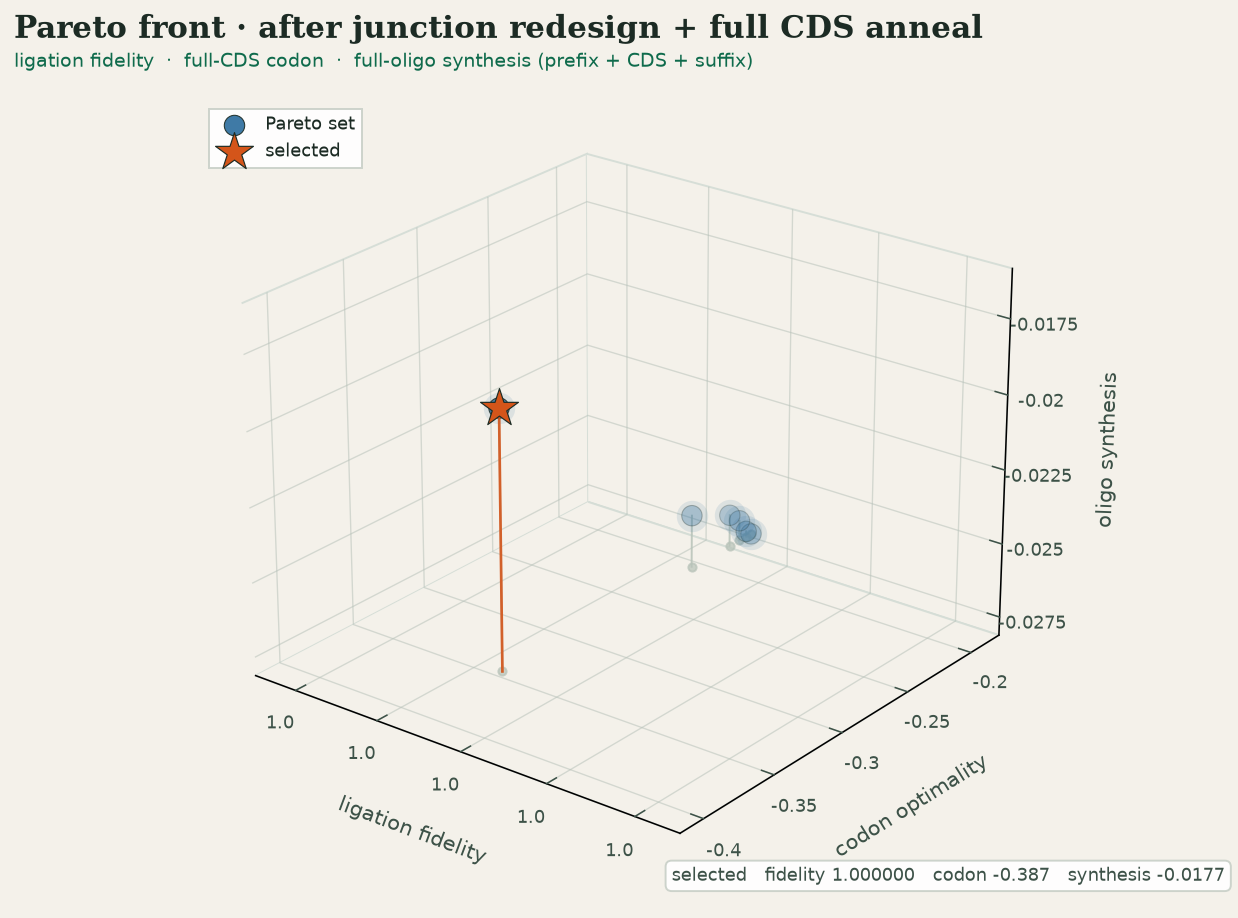

✓ Pareto plot ready.


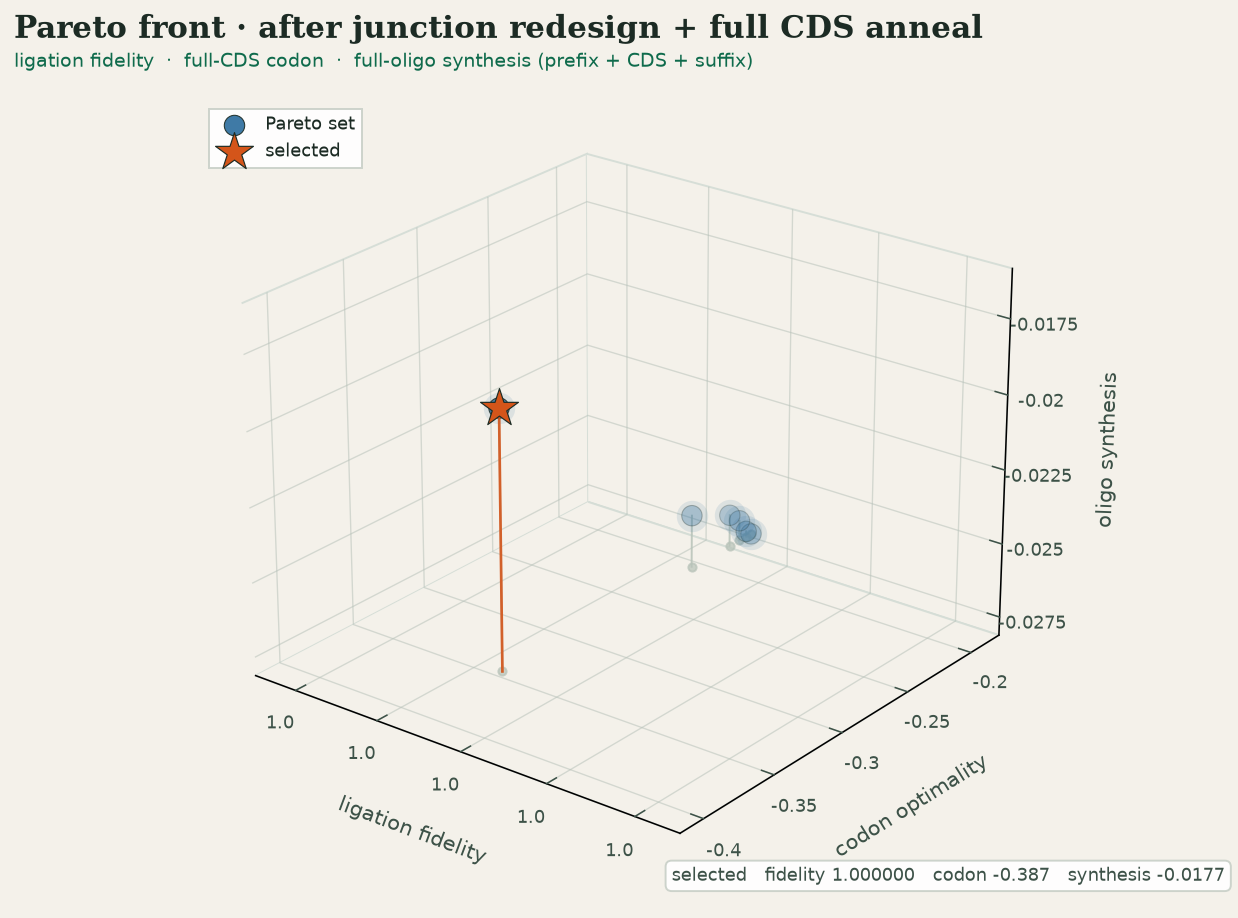

In [23]:
ui.section(
    "Pareto front (after junction redesign + full CDS anneal)",
    "Requires both steps. Selected point uses the annealed library; "
    "other front members get greedy CDS + full-oligo scores.",
)

RUN_PARETO_PLOT = True
DEEP_RESCORE_ALL = False  # True = full-anneal every front member (slow)

_front = globals().get("PARETO_FRONT")
_selected = globals().get("SELECTED_OVERHANGS")
_library = globals().get("optimized_library")
_parts = globals().get("parts")

if not RUN_PARETO_PLOT:
    ui.note("RUN_PARETO_PLOT = False — skipped.")
elif _library is None or getattr(_library, "empty", False):
    ui.note(
        "Run <b>Final library optimize</b> first. "
        "The Pareto plot only appears after junction redesign <i>and</i> full CDS anneal."
    )
else:
    if _front is None or getattr(_front, "empty", True):
        if (OUTPUT_DIR / "pareto_front.csv").exists():
            _front = pd.read_csv(OUTPUT_DIR / "pareto_front.csv")
            PARETO_FRONT = _front
        else:
            ui.note("No Pareto front — run overhang redesign first.")
            _front = None

    if _front is not None and not getattr(_front, "empty", True):
        if _selected is None and (OUTPUT_DIR / "selected_overhangs.csv").exists():
            sel = pd.read_csv(OUTPUT_DIR / "selected_overhangs.csv")
            if "overhangs" in sel.columns:
                _selected = parse_overhang_selection(sel.iloc[0]["overhangs"])
                SELECTED_OVERHANGS = _selected

        if _parts is None and CONFIG["parts_file"].exists():
            _parts = load_and_validate_parts(CONFIG["parts_file"])
            parts = _parts

        junction_map = pd.read_csv(INPUT_DIR / "junction_map.csv")
        print("▶ Scoring Pareto front after junction redesign + full CDS anneal…")
        PARETO_FRONT_DEEP = rescore_pareto_front_after_anneal(
            _front,
            parts=_parts,
            junction_map=junction_map,
            codon_data=CODON_DATA,
            config=CONFIG,
            optimize_coding_sequence=optimize_coding_sequence,
            selected_overhangs=_selected,
            optimized_library=_library,
            fidelity=globals().get("FIDELITY"),
            deep_all=DEEP_RESCORE_ALL,
            output_dir=OUTPUT_DIR,
            log=print,
        )
        display(PARETO_FRONT_DEEP)

        fig, ax, chosen = plot_pareto_front(
            PARETO_FRONT_DEEP,
            selected_overhangs=_selected,
            selection_mode=CONFIG.get("overhang_redesign", {}).get("selection", "knee"),
            save_path=OUTPUT_DIR / "pareto_front.png",
            title="Pareto front · after junction redesign + full CDS anneal",
        )
        display(fig)
        ui.status(
            f"Selected · <b>full-oligo</b> synthesis <b>{float(chosen['synthesis']):.3f}</b> "
            f"<span style='color:#3d5248'>(prefix+CDS+suffix; higher is better)</span> · "
            f"CDS codon <b>{float(chosen['codon_optimality']):.3f}</b> · "
            f"fidelity <b>{float(chosen['ligation_fidelity']):.6f}</b><br>"
            f"Plot → <code>{OUTPUT_DIR / 'pareto_front.png'}</code>"
        )
        print("✓ Pareto plot ready.")


## Export results

Orderable oligos after redesign + final codon optimization.


In [24]:
if optimized_library is not None:
    output_csv = OUTPUT_DIR / "optimized_grasp_oligos.csv"
    output_fasta = OUTPUT_DIR / "optimized_grasp_oligos.fasta"
    output_xlsx = OUTPUT_DIR / "optimized_grasp_library.xlsx"

    optimized_library.to_csv(output_csv, index=False)

    with open(output_fasta, "w") as handle:
        for row in optimized_library.itertuples(index=False):
            handle.write(
                f">{row.optimized_part_id}"
                f"|length={row.oligo_length}"
                f"|qc={row.qc_passed}\n"
            )
            handle.write(row.oligo_sequence_5to3 + "\n")

    qc_cols = [
        c for c in [
            "optimized_part_id",
            "translation_verified",
            "mask_verified",
            "codon_score",
            "cds_gc",
            "cds_repeat_penalty",
            "oligo_warnings",
            "oligo_failures",
            "qc_passed",
            "selected_overhangs",
        ]
        if c in optimized_library.columns
    ]

    with pd.ExcelWriter(output_xlsx) as writer:
        optimized_library.to_excel(writer, sheet_name="oligos", index=False)
        optimized_library[qc_cols].to_excel(writer, sheet_name="QC", index=False)

    ui.status(
        "Exported:<br/>"
        f"• <code>{output_csv}</code><br/>"
        f"• <code>{output_fasta}</code><br/>"
        f"• <code>{output_xlsx}</code>"
    )
else:
    ui.note("No export yet — run the final library optimization first.")


# Target Compiler

After the plasmid library is built once, this section maps any target RNA onto existing plasmids.

## Load target map


In [25]:
def load_target_map(path):
    mapping = pd.read_csv(path)
    required = {
        "architecture",
        "target_position",
        "target_base",
        "part_id",
        "assembly_group",
        "assembly_order",
    }
    missing = required - set(mapping.columns)
    if missing:
        raise ValueError(f"target_map.csv missing columns: {missing}")

    mapping["target_base"] = (
        mapping["target_base"]
        .astype(str)
        .str.upper()
        .str.replace("T", "U", regex=False)
    )
    mapping["target_position"] = pd.to_numeric(
        mapping["target_position"], errors="raise"
    ).astype(int)
    return mapping


try:
    target_map = load_target_map(CONFIG["target_map_file"])
    if target_map["part_id"].astype(str).str.contains("REPLACE").any():
        raise ValueError("target_map.csv still contains placeholders.")
    ui.status(
        f"Target catalog: {len(target_map)} rows · "
        "use compile_target_gap() for real assembly plans"
    )
    display(target_map.head())
except Exception as error:
    print("Target catalog not ready:")
    print(error)
    target_map = None


,architecture,target_position,target_base,part_id,assembly_group,assembly_order,code_suffix,note
0,9S,1,A,1A_5T_AGGT,CDS1,1,_5T,half-code 5th AA; full motif depends on next part
1,9S,1,G,1A_5T_AGGT,CDS1,1,_5T,half-code 5th AA; full motif depends on next part
2,9S,1,A,1A_5T_AATG,CDS1,1,_5T,half-code 5th AA; full motif depends on next part
3,9S,1,G,1A_5T_AATG,CDS1,1,_5T,half-code 5th AA; full motif depends on next part
4,9S,1,C,1A_5N_AGGT,CDS1,1,_5N,half-code 5th AA; full motif depends on next part


## Compile target RNA → assembly plan

In [26]:
def normalize_rna(sequence):
    sequence = str(sequence).upper()
    sequence = re.sub(r"\s+", "", sequence)
    sequence = sequence.replace("T", "U")
    invalid = set(sequence) - set("ACGU")
    if invalid:
        raise ValueError(f"Invalid RNA characters: {invalid}")
    return sequence


def compile_target(
    target_rna,
    target_map=None,
    architecture="9S",
    version_assignment=None,
    nterm_overhang="AGGT",
):
    """Compile RNA → ordered GRASP parts using the paper GAP algorithm."""
    plan = compile_target_gap(
        target_rna,
        architecture=architecture,
        nterm_overhang=nterm_overhang,
    )
    if version_assignment:
        plan["optimized_part_id"] = plan["part_id"].map(
            lambda p: f"{p}_v{version_assignment.get(p, 1)}"
        )
    # Optional sanity check against catalog
    if target_map is not None:
        known = set(target_map["part_id"])
        missing = sorted(set(plan["part_id"]) - known)
        if missing:
            raise ValueError(f"GAP selected unknown part_ids: {missing}")
    return plan


# Example: rpoA-style 9-mer from Farley et al. (p0 code ND.ND.TN.NN.TN.NN.TD.ND.TD)
TARGET_RNA = CONFIG.get("target_rna", "UUACACGUG")

if CONFIG["parts_file"].exists():
    assembly_plan = compile_target(
        TARGET_RNA,
        target_map=target_map,
        architecture=CONFIG.get("architecture", "9S"),
        nterm_overhang=CONFIG.get("nterm_overhang", "AGGT"),
    )
    display(assembly_plan)
    assembly_plan.to_csv(
        OUTPUT_DIR / f"assembly_plan_{TARGET_RNA}.csv",
        index=False,
    )
else:
    print("Import GRASP parts first.")


NotImplementedError: Importer currently wires 9S binding targets

# Inspect assembled CDS

## Simulate assembled CDS

This function concatenates optimized CDS sequences in the order set by the target compiler. For the original GRASP segmentation architecture, check that the CDS regions stored in `parts.csv` are non-overlapping.


In [27]:
def simulate_assembled_cds(
    assembly_plan,
    optimized_library,
    parts_full=None,
):
    """Stitch optimized module CDS with shared 4-nt overhangs deduplicated.

    Each part coding window includes both overhangs. Downstream modules contribute
    only the DNA after their 5′ overhang so junctions are not doubled.
    """
    selected = assembly_plan.merge(
        optimized_library[
            [
                "optimized_part_id",
                "optimized_cds",
                "aa_sequence",
                "part_id",
            ]
        ],
        on="optimized_part_id",
        how="left",
        validate="many_to_one",
    )

    if selected["optimized_cds"].isna().any():
        missing = selected.loc[
            selected["optimized_cds"].isna(),
            "optimized_part_id",
        ].tolist()
        raise ValueError(f"Missing optimized sequences for: {missing}")

    sort_cols = [c for c in ("assembly_group", "assembly_order", "assembly_slot") if c in selected.columns]
    selected = selected.sort_values(sort_cols)

    if parts_full is None:
        parts_full_path = INPUT_DIR / "parts_full.csv"
        parts_full = pd.read_csv(parts_full_path) if parts_full_path.exists() else None

    chunks = []
    expected_chunks = []
    for i, row in enumerate(selected.itertuples(index=False)):
        cds = clean_dna(row.optimized_cds)
        aa = str(row.aa_sequence).upper().replace(" ", "")
        if parts_full is not None and row.part_id in set(parts_full["part_id"]):
            meta = parts_full.set_index("part_id").loc[row.part_id]
            oh5 = int(meta.oh5_mask_start)
            if i == 0:
                chunks.append(cds)
                expected_chunks.append(aa)
            else:
                # drop shared 5′ overhang already present at end of previous chunk
                chunks.append(cds[oh5 + 4 :])
                # protein: drop residues wholly encoded by the shared overhang window
                drop_aa = (oh5 + 4) // 3
                expected_chunks.append(aa[drop_aa:])
        else:
            chunks.append(cds)
            expected_chunks.append(aa)

    assembled_cds = "".join(chunks)
    expected_protein = "".join(expected_chunks)
    observed_protein = translate_dna(assembled_cds, CONFIG["genetic_code"])
    qc = synthesis_qc(assembled_cds, CONFIG)

    return {
        "assembled_cds": assembled_cds,
        "expected_protein": expected_protein,
        "observed_protein": observed_protein,
        "translation_verified": observed_protein == expected_protein,
        **qc,
    }


parts_full = None
if (INPUT_DIR / "parts_full.csv").exists():
    parts_full = pd.read_csv(INPUT_DIR / "parts_full.csv")

if optimized_library is not None and CONFIG["parts_file"].exists():
    assembly_plan = compile_target(
        TARGET_RNA,
        target_map=target_map,
        architecture="9S",
    )
    assembled = simulate_assembled_cds(
        assembly_plan,
        optimized_library,
        parts_full=parts_full,
    )
    for key, value in assembled.items():
        if key not in {"assembled_cds", "expected_protein", "observed_protein"}:
            print(f"{key}: {value}")
    with open(OUTPUT_DIR / f"assembled_{TARGET_RNA}.fasta", "w") as handle:
        handle.write(f">GRASP_{TARGET_RNA}\n")
        handle.write(assembled["assembled_cds"] + "\n")
else:
    print("Assembly QC skipped: optimize the library first.")


AttributeError: 'Pandas' object has no attribute 'part_id'

# Notes

**GRASP** — Farley et al., *Nucleic Acids Res.* 2025 ([paper](https://academic.oup.com/nar/article/53/20/gkaf1169/8321212), [GenBank](https://github.com/farleykvdg/GRASP)).

**Twist synthesis** (from Twist FAQ / Complex Genes; ML scorer is proprietary):
- Hard: avoid homopolymers ≥14 bp; no CcdB
- Standard guidelines: GC 25–65%, minimize long repeats (≥20 bp), keep 50 bp GC windows from swinging wildly, homopolymers ≤13 nt preferred
- Oligo pools 20–300 bp · Gene Fragments / Clonal Genes ~0.3–5 kb (Complex up to ~7 kb)
- Pick a Twist profile in the control panel; GRASP modules are short → usually **oligo-pool scale** unless you pad to ≥300 bp

**Re-import GenBank:** control panel → Reload, or `python -m grasp_library.import_grasp`
